In [70]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [65]:
# ------------------------------------------------------------
# Conceptual behavioral state space
# Coordinates:
# x = Phi_trans
# y = Phi_tan
# z = Phi_rad^±
# ------------------------------------------------------------

states = {
    "Traveling":  (1.0, 0.0,  0.0),
    "Milling":    (0.0, 1.0,  0.0),
    "Shoaling":   (0.0, 0.0,  0.0),
    "Expansion":  (0.0, 0.0,  1.0),
    "Compaction": (0.0, 0.0, -1.0),
}

# Colors can be changed freely.
colors = {
    "Traveling":  "tab:blue",
    "Milling":    "tab:purple",
    "Shoaling":   "tab:green",
    "Expansion":  "tab:orange",
    "Compaction": "tab:red",
}

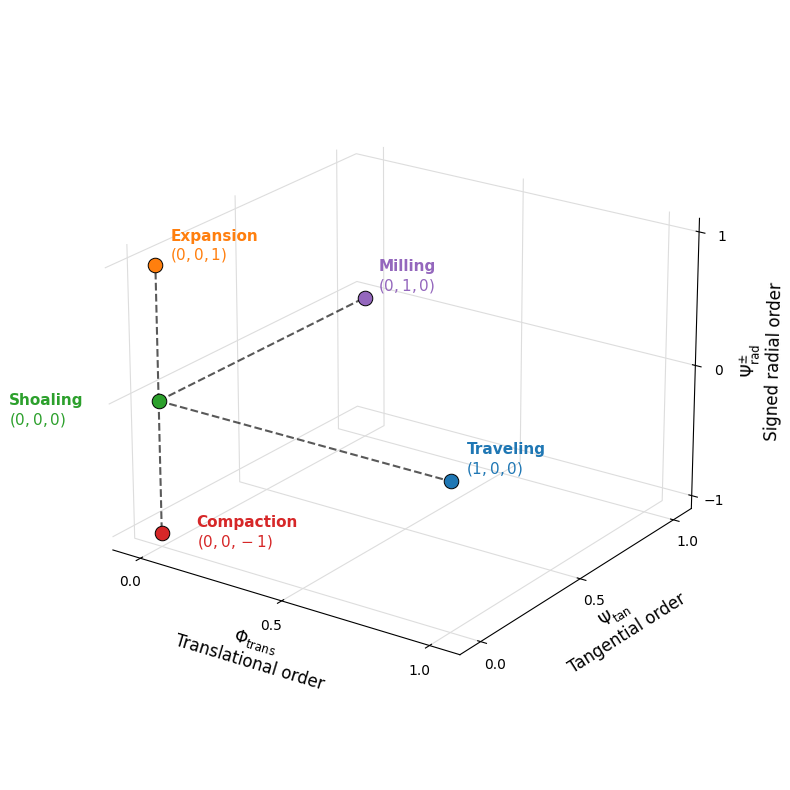

In [73]:
plt.rcParams['grid.color'] = '#dddddd'

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# State points + projection lines
# ------------------------------------------------------------

for name, (x, y, z) in states.items():

    color = colors[name]

    ax.scatter(
        x, y, z,
        s=110,
        color=color,
        edgecolor="black",
        linewidth=0.7,
        depthshade=False,
        zorder=10
    )

    # Dashed projection lines toward the origin
    ax.plot(
        [0, x],
        [0, y],
        [0, z],
        linestyle="--",
        linewidth=1.5,
        color='k',
        alpha=0.65
    )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.text(
    1.03, 0.03, 0.05,
    "Traveling\n$(1,0,0)$",
    color=colors["Traveling"],
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.03, 1.03, 0.05,
    "Milling\n$(0,1,0)$",
    color=colors["Milling"],
    fontsize=11,
    fontweight="bold"
)

ax.text(
    -0.3, -0.3, -0.1,
    "Shoaling\n$(0,0,0)$",
    color=colors["Shoaling"],
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.03, 0.03, 1.03,
    "Expansion\n$(0,0,1)$",
    color=colors["Expansion"],
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.07, 0.07, -1.12,
    "Compaction\n$(0,0,-1)$",
    color=colors["Compaction"],
    fontsize=11,
    fontweight="bold"
)

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xlabel(
    r"$\Phi_{\mathrm{trans}}$"
    "\nTranslational order",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    r"$\Phi_{\mathrm{tan}}$"
    "\nTangential order",
    fontsize=12,
    labelpad=12
)

ax.set_zlabel(
    r"$\Phi_{\mathrm{rad}}^{\pm}$"
    "\nSigned radial order",
    fontsize=12,
    labelpad=12
)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_zlim(-1.1, 1.1)

ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 0.5, 1])
ax.set_zticks([-1, 0, 1])

# Equal-ish visual scaling
ax.set_box_aspect((1, 1, 1))

# Viewing angle
ax.view_init(elev=22, azim=-55)

# Light grid
# ax.grid(True, color="#eeeeee")

# Transparent panes for a cleaner publication appearance
ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ax.set_title(
#     "Conceptual behavioral state space",
#     fontsize=15,
#     pad=18
# )

ax.set_box_aspect(None, zoom=0.85)
plt.tight_layout()
plt.show()

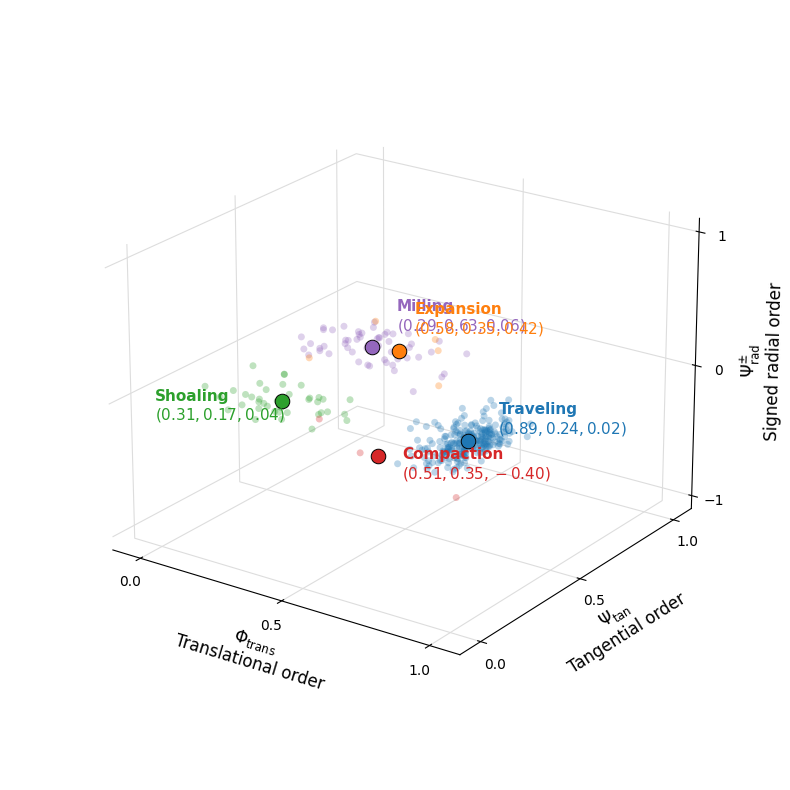

In [76]:
ann = pd.read_csv("annotated_features.csv")
label_to_state = {
    "traveling_polarized": "Traveling",
    "milling": "Milling",
    "shoaling": "Shoaling",
    "expansion_burst": "Expansion",
    "compaction": "Compaction",
}

with open("results/calibration_report.json", encoding="utf-8") as f:
    couzin = json.load(f)

real_states = {}
for canon, name in label_to_state.items():
    feats = couzin[canon]["features"]
    real_states[name] = (
        float((feats.get("phi_trans") or feats["phi_trans_mean"])["mean"]),
        float((feats.get("phi_tan") or feats["phi_tan_mean"])["mean"]),
        float((feats.get("phi_rad_pm") or feats["phi_rad_pm_mean"])["mean"]),
    )

plt.rcParams['grid.color'] = '#dddddd'

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.computed_zorder = False

for label, name in label_to_state.items():
    sub = ann[ann["label"] == label]
    ax.scatter(
        sub["phi_trans"],
        sub["phi_tan"],
        sub["phi_rad_pm"],
        s=25,
        color=colors[name],
        edgecolors="none",
        alpha=0.3,
        depthshade=False,
        zorder=1,
        label=name,
    )

for name, (x, y, z) in real_states.items():
    ax.scatter(
        x, y, z,
        s=110,
        color=colors[name],
        edgecolor="black",
        linewidth=0.7,
        depthshade=False,
        zorder=5,
    )

label_offset = {
    "Traveling": (0.08, 0.03, 0.08),
    "Milling": (0.03, 0.08, 0.08),
    "Shoaling": (-0.28, -0.22, -0.12),
    "Expansion": (0.03, 0.03, 0.12),
    "Compaction": (0.05, 0.05, -0.18),
}
for name, (x, y, z) in real_states.items():
    dx, dy, dz = label_offset[name]
    ax.text(
        x + dx, y + dy, z + dz,
        f"{name}\n$({x:.2f},{y:.2f},{z:.2f})$",
        color=colors[name],
        fontsize=11,
        fontweight="bold",
        zorder=6,
    )

ax.set_xlabel(
    r"$\Phi_{\mathrm{trans}}$"
    "\nTranslational order",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    r"$\Phi_{\mathrm{tan}}$"
    "\nTangential order",
    fontsize=12,
    labelpad=12
)

ax.set_zlabel(
    r"$\Phi_{\mathrm{rad}}^{\pm}$"
    "\nSigned radial order",
    fontsize=12,
    labelpad=12
)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_zlim(-1.1, 1.1)

ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 0.5, 1])
ax.set_zticks([-1, 0, 1])

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=22, azim=-55)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

ax.set_box_aspect(None, zoom=0.85)
plt.tight_layout()
plt.show()


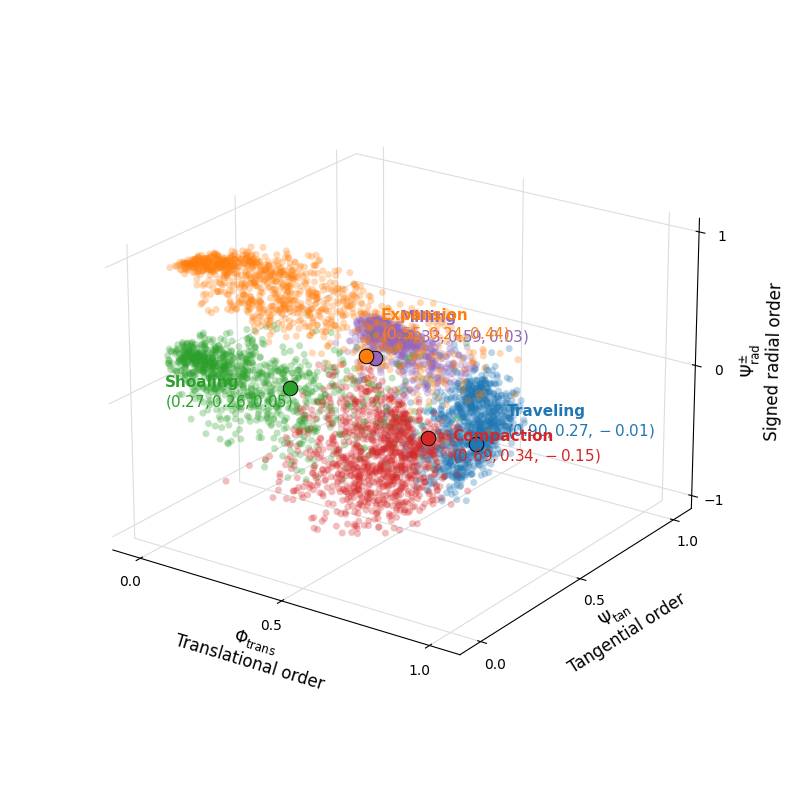

In [77]:
label_to_state = {
    "traveling_polarized": "Traveling",
    "milling": "Milling",
    "shoaling": "Shoaling",
    "expansion_burst": "Expansion",
    "compaction": "Compaction",
}

with open("sim_datasets/manifest.json", encoding="utf-8") as f:
    manifest = json.load(f)

sim_rows = []
for e in manifest:
    lab = e.get("behavior", "")
    if not e.get("valid", False) or lab not in label_to_state:
        continue
    m = e.get("metrics") or {}
    sim_rows.append({
        "label": lab,
        "phi_trans": float(m.get("phi_trans_mean", 0.0)),
        "phi_tan": float(m.get("phi_tan_mean", m.get("psi_tan_mean", 0.0))),
        "phi_rad": float(m.get("phi_rad_pm_mean", m.get("psi_rad_pm_mean", 0.0))),
        "phi_tan_unsigned": float(m.get("phi_tan_unsigned_mean", 0.0)),
        "phi_local": float(m.get("phi_local_mean", 0.0)),
    })
sim = pd.DataFrame(sim_rows)

with open("results/tuning/feature_match/best.json", encoding="utf-8") as f:
    tuned = json.load(f)

synth_states = {}
for canon, name in label_to_state.items():
    feats = tuned["sim_features"][canon]
    tan = feats.get("phi_tan_mean", feats.get("psi_tan_mean", {}))
    rad = feats.get("phi_rad_pm_mean", feats.get("psi_rad_pm_mean", {}))
    synth_states[name] = (
        float(feats["phi_trans_mean"]["mean"]),
        float(tan["mean"]),
        float(rad["mean"]),
        float(feats.get("phi_tan_unsigned_mean", {}).get("mean", 0.0)),
        float(feats.get("phi_local_mean", {}).get("mean", 0.0)),
    )

plt.rcParams['grid.color'] = '#dddddd'

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.computed_zorder = False

for label, name in label_to_state.items():
    sub = sim[sim["label"] == label]
    ax.scatter(
        sub["phi_trans"],
        sub["phi_tan"],
        sub["phi_rad"],
        s=25,
        color=colors[name],
        edgecolors="none",
        alpha=0.3,
        depthshade=False,
        zorder=1,
        label=name,
    )

for name, xyz in synth_states.items():
    x, y, z = xyz[:3]
    ax.scatter(
        x, y, z,
        s=110,
        color=colors[name],
        edgecolor="black",
        linewidth=0.7,
        depthshade=False,
        zorder=5,
    )

label_offset = {
    "Traveling": (0.08, 0.03, 0.08),
    "Milling": (0.03, 0.08, 0.08),
    "Shoaling": (-0.28, -0.22, -0.12),
    "Expansion": (0.03, 0.03, 0.12),
    "Compaction": (0.05, 0.05, -0.18),
}
for name, xyz in synth_states.items():
    x, y, z = xyz[:3]
    dx, dy, dz = label_offset[name]
    ax.text(
        x + dx, y + dy, z + dz,
        f"{name}\n$({x:.2f},{y:.2f},{z:.2f})$",
        color=colors[name],
        fontsize=11,
        fontweight="bold",
        zorder=6,
    )

ax.set_xlabel(
    r"$\Phi_{\mathrm{trans}}$"
    "\nTranslational order",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    r"$\Phi_{\mathrm{tan}}$"
    "\nTangential order",
    fontsize=12,
    labelpad=12
)

ax.set_zlabel(
    r"$\Phi_{\mathrm{rad}}^{\pm}$"
    "\nSigned radial order",
    fontsize=12,
    labelpad=12
)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_zlim(-1.1, 1.1)

ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 0.5, 1])
ax.set_zticks([-1, 0, 1])

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=22, azim=-55)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

ax.set_box_aspect(None, zoom=0.85)
plt.tight_layout()
plt.show()


explained variance ratio: [0.45463762 0.37869424]
cumulative: 0.8333318616548155
loadings (PC1, PC2) for ['phi_trans', 'psi_tan', 'psi_rad']
[[-0.54346982 -0.6204101 ]
 [-0.36037162  0.78081762]
 [ 0.75813776 -0.07358775]]


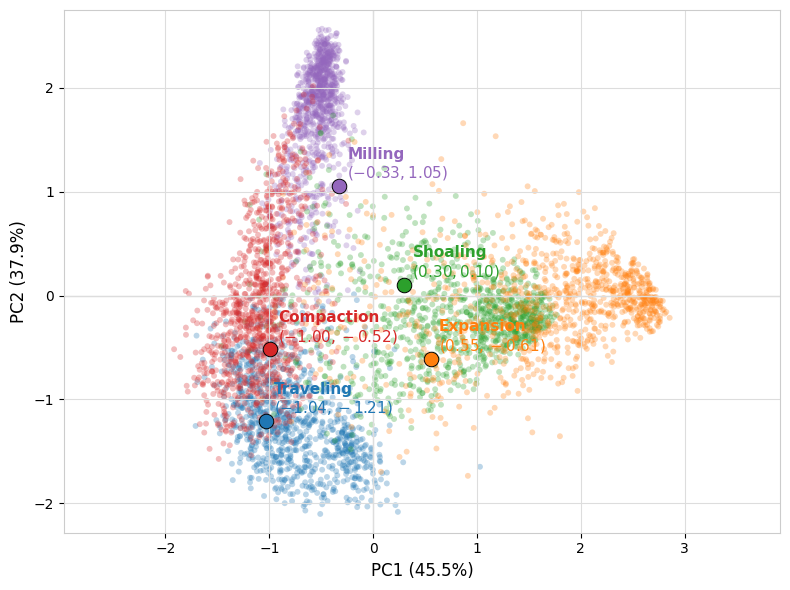

In [78]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feat_cols = [
    "phi_trans",
    "phi_tan",
    "phi_rad",
    "phi_tan_unsigned",
    "phi_local",
]
X = sim[feat_cols].to_numpy(dtype=float)
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
Z = pca.fit_transform(X_std)

print("explained variance ratio:", pca.explained_variance_ratio_)
print("cumulative:", pca.explained_variance_ratio_.sum())
print("loadings (PC1, PC2) for", feat_cols)
print(pca.components_.T)

sim_pca = sim.copy()
sim_pca["pc1"] = Z[:, 0]
sim_pca["pc2"] = Z[:, 1]

means = sim[feat_cols].mean().to_numpy()
stds = sim[feat_cols].std(ddof=0).to_numpy()
synth_pca = {
    name: pca.transform(((np.array(xyz) - means) / stds).reshape(1, -1))[0]
    for name, xyz in synth_states.items()
}

fig, ax = plt.subplots(figsize=(8, 6))
for label, name in label_to_state.items():
    sub = sim_pca[sim_pca["label"] == label]
    ax.scatter(
        sub["pc1"],
        sub["pc2"],
        s=18,
        color=colors[name],
        edgecolors="none",
        alpha=0.3,
        zorder=1,
        label=name,
    )

for name, (x, y) in synth_pca.items():
    ax.scatter(
        x, y,
        s=110,
        color=colors[name],
        edgecolor="black",
        linewidth=0.7,
        zorder=5,
    )
    ax.text(
        x + 0.08, y + 0.08,
        f"{name}\n$({x:.2f},{y:.2f})$",
        color=colors[name],
        fontsize=11,
        fontweight="bold",
        zorder=6,
    )

ax.set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)", fontsize=12)
ax.set_aspect("equal", adjustable="datalim")
ax.axhline(0, color="#dddddd", linewidth=1)
ax.axvline(0, color="#dddddd", linewidth=1)
for spine in ax.spines.values():
    spine.set_color("#cccccc")
plt.tight_layout()
plt.show()
